## Set-Up Code

In [1]:
!pip install konda
import konda
konda.install()

!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
!conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r

Installing Miniconda to /usr/local...
✅ Miniconda installed successfully!
Run '!conda --version' to check if conda is working.

📋 Usage examples:
  konda create -n my_env python=3.11 -y
  konda activate my_env
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r


In [2]:
# Create a new environment
!konda create -n osim_env python=3.11 -y

# Activate the environment
!konda activate osim_env

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / - \ | / done
Channels:
 - defaults
Platform: linux-64
Solving environment: | done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /usr/local/envs/osim_env

  added / updated specs:
    - python=3.11


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    expat-2.7.4                |       h7354ed3_0          25 KB
    libexpat-2.7.4             |       h7354ed3_0         122 KB
    libnsl-2.0.0               |       h5eee18b_0          31 KB
    openssl-3.5.5              |       h1b28b03_0         5.5 MB
    packaging-25.0          

In [3]:
!konda run "conda install -qyc opensim-org opensim=4.5"
!konda run "pip install matplotlib numpy pandas anytree"

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - opensim-org
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local/envs/osim_env

  added / updated specs:
    - opensim=4.5


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blas-1.0                   |         openblas          46 KB
    libgfortran-15.2.0         |       h166f726_7          28 KB
    libgfortran-ng-15.2.0      |       h166f726_7          28 KB
    libgfortran5-15.2.0        |       hc633d37_7         1.5 MB
    libopenblas-0.3.31         |       hf7dbefb_0         5.7 MB
    nomkl-3.0                  |                0          46 KB
    numpy-2.0.1                |  py311h24aa872_1          11 KB
    numpy-base-2.0.1           |  py311hbfb1bba_1         9.1 MB
    openblas-0.3.31            |       h06a4308_0          12 KB
   

In [4]:
import subprocess, sys, textwrap, shlex, uuid, threading, queue, time
from IPython import get_ipython

_KPY_Q = queue.Queue()
_KPY_PROC = None
_KPY_READER = None

def _kpy_start():
    global _KPY_PROC, _KPY_READER

    worker = r"""
import sys, traceback

G = {}  # persistent globals live here

def run_block(tag, lines):
    src = "".join(lines)
    try:
        codeobj = compile(src, "<kpy>", "exec")
        exec(codeobj, G, G)
    except Exception:
        traceback.print_exc()
    # ALWAYS emit done marker
    sys.stdout.write(f"__KPY_DONE__ {tag}\n")
    sys.stdout.flush()

while True:
    header = sys.stdin.readline()
    if not header:
        break
    header = header.rstrip("\n")
    if not header.startswith("__KPY_BEGIN__ "):
        continue
    tag = header.split(" ", 1)[1]

    lines = []
    while True:
        line = sys.stdin.readline()
        if not line:
            # stdin closed
            sys.exit(0)
        if line.rstrip("\n") == f"__KPY_END__ {tag}":
            break
        lines.append(line)

    run_block(tag, lines)
"""

    # konda wants a single string command, per your working example
    cmd_str = f"python -u -c {shlex.quote(worker)}"
    full = ["bash", "-lc", f"konda run {shlex.quote(cmd_str)}"]

    _KPY_PROC = subprocess.Popen(
        full,
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    def reader():
        for line in _KPY_PROC.stdout:
            _KPY_Q.put(line)
        _KPY_Q.put(None)  # process ended sentinel

    _KPY_READER = threading.Thread(target=reader, daemon=True)
    _KPY_READER.start()

def _kpy_ensure_started():
    if "_KPY_PROC" not in globals() or _KPY_PROC is None or _KPY_PROC.poll() is not None:
        _kpy_start()

def _kpy_send(code: str, timeout_s: float = 60.0):
    _kpy_ensure_started()
    tag = uuid.uuid4().hex
    code = textwrap.dedent(code).rstrip() + "\n"

    # send delimited block
    _KPY_PROC.stdin.write(f"__KPY_BEGIN__ {tag}\n")
    _KPY_PROC.stdin.write(code)
    _KPY_PROC.stdin.write(f"__KPY_END__ {tag}\n")
    _KPY_PROC.stdin.flush()

    done_line = f"__KPY_DONE__ {tag}\n"
    t0 = time.time()

    # read from queue until done marker or timeout
    while True:
        remaining = timeout_s - (time.time() - t0)
        if remaining <= 0:
            raise TimeoutError(
                "%%kpy timed out waiting for completion marker. "
                "Your code may be stuck (infinite loop / blocking call)."
            )

        item = _KPY_Q.get(timeout=remaining)
        if item is None:
            raise RuntimeError("kpy worker process exited unexpectedly.")
        if item == done_line:
            break
        sys.stdout.write(item)
        sys.stdout.flush()

def _kpy_cell(line, cell):
    # allow: %%kpy --timeout=120
    timeout = 60.0
    line = (line or "").strip()
    if line.startswith("--timeout="):
        timeout = float(line.split("=", 1)[1])
    _kpy_send(cell, timeout_s=timeout)

def _kpy_reset(line=""):
    global _KPY_PROC
    if _KPY_PROC is not None and _KPY_PROC.poll() is None:
        try:
            _KPY_PROC.terminate()
        except Exception:
            pass
    _KPY_PROC = None
    print("✅ kpy worker reset. Next %%kpy will start a fresh persistent session.")

ip = get_ipython()
ip.register_magic_function(_kpy_cell, magic_kind="cell", magic_name="kpy")
ip.register_magic_function(_kpy_reset, magic_kind="line", magic_name="kpyreset")

print("✅ Persistent %%kpy ready. Variables persist across %%kpy cells.")
print("   Use: %%kpy  (optionally: %%kpy --timeout=120)  and reset with: %kpyreset")

✅ Persistent %%kpy ready. Variables persist across %%kpy cells.
   Use: %%kpy  (optionally: %%kpy --timeout=120)  and reset with: %kpyreset


In [5]:
%%kpy
import os
os.environ["MPLBACKEND"] = "Agg"  # headless backend

import matplotlib
matplotlib.use("Agg", force=True)

## Helper Functions

#### Part 1 Helpers

In [6]:
## Part 1 Helpers
%%kpy

from anytree import Node, RenderTree

def build_kinematic_tree(model):

  joints = m.getJointSet()
  jointbodyTuples = []

  for jnt in joints:
      jnt_name = jnt.getName()
      coordinate_names = []
      for i in range(3): #lazy way to handle more coordinates for pelvis
        try:
          coordinate_names.append(jnt.get_coordinates(i).getName())
        except:
          continue

      coordinate_name = ', '.join(coordinate_names)

      parent_body = jnt.getParentFrame().getSocket('parent').getConnecteeAsObject().getName()
      child_body = jnt.getChildFrame().getSocket('parent').getConnecteeAsObject().getName()
      jointbodyTuples.append((parent_body, coordinate_name, child_body))

  #loop through jointbodyTuples
  tree_nodes = []
  tree_nodes.append(Node('ground'))
  for parent_body, jnt_name, child_body in jointbodyTuples[:]:
      curr_node = Node(name=child_body, parent=tree_nodes[[n.name for n in tree_nodes].index(parent_body)])
      curr_node.joint_from_parent = jnt_name
      tree_nodes.append(curr_node)

  return tree_nodes

def print_help_tree():
  print("Example of kinematic tree structure:\n")
  example_node = Node("Parent Body")
  example_child = Node("Child Body", parent=example_node)
  example_child.joint_from_parent = "Connecting Joint to Parent Body"
  for pre, fill, node in RenderTree(example_node):
    j = getattr(node, "joint_from_parent", "")
    j = f"({j})" if j else ""
    print(f"{pre} {node.name}  {j}")

  print("\n\n")


def print_tree(tree_nodes):
  for pre, fill, node in RenderTree(tree_nodes[0]):
    j = getattr(node, "joint_from_parent", "")
    j = f"({j})" if j else ""
    print(f"{pre}{node.name}  {j}")


def collect_muscle_path_attachements(muscle):
  musc_path = muscle.getComponent('path')
  return [pt.getParentFrame().getName() for pt in musc_path.getPathPointSet()]

#### Part 2 Helpers

In [7]:
%%kpy
import numpy as np

def grab_qpos_zip(df, idx):
  df_no_time = df.loc[:, kin.columns != 'time']
  return df_no_time.iloc[idx].items()

def position_model(m, qpos_zip):
  s = m.initSystem()
  for key,val in qpos_zip:
    m.getCoordinateSet().get(key).setValue(s,val)

  m.assemble(s)
  m.realizePosition(s)
  return m,s

def compute_muscle_moment_arm(m, qpos_zip, muscle, dof):
  m, s = position_model(m, qpos_zip)
  musc = m.getMuscles().get(muscle)
  coord = m.getCoordinateSet().get(dof)
  muscle_ma = musc.computeMomentArm(s, coord)
  return muscle_ma

def compute_moment_arms_during_motion(muscle, m, df, dof, save=False):
  mas = []
  for idx in range(len(df)):
    qpos_zip = grab_qpos_zip(df, idx)
    # print([*qpos_zip])
    mas.append(compute_muscle_moment_arm(m, qpos_zip, muscle, dof))

  mas = np.array(mas)
  # time = df['time']
  # dof_angles = df[dof]

  if save:
    np.save(f"{muscle}_MomentArm_wrt_{dof}", mas)


  return mas

In [25]:
import matplotlib.pyplot as plt
import numpy as np


def load_and_plot_mas(muscle, dof, df, xaxis='time'):
  mas = np.load(f"{muscle}_MomentArm_wrt_{dof}.npy", allow_pickle=True)
  xaxis_plt = df[xaxis]
  plt.plot(xaxis_plt,mas)
  # plt.legend()
  plt.xlabel(xaxis.capitalize())
  plt.ylabel("Moment Arm (m)")

## Assignment

In [11]:
%%kpy
#Load Model
import opensim as osim
m = osim.Model("/content/gait10dof18musc_updated.osim")
initial_state = m.initSystem()

[info] Updating Model file from 30000 to latest format...
[info] Loaded model gait10dof18musc.osim from file /content/gait10dof18musc_updated.osim
[warning] Couldn't find file 'sacrum.vtp'.
[warning] Couldn't find file 'pelvis.vtp'.
[warning] Couldn't find file 'l_pelvis.vtp'.
[warning] Couldn't find file 'femur_r.vtp'.
[warning] Couldn't find file 'tibia_r.vtp'.
[warning] Couldn't find file 'fibula.vtp'.
[warning] Couldn't find file 'talus.vtp'.
[warning] Couldn't find file 'foot.vtp'.
[warning] Couldn't find file 'bofoot.vtp'.
[warning] Couldn't find file 'femur_l.vtp'.
[warning] Couldn't find file 'tibia_l.vtp'.
[warning] Couldn't find file 'l_fibula.vtp'.
[warning] Couldn't find file 'l_talus.vtp'.
[warning] Couldn't find file 'l_foot.vtp'.
[warning] Couldn't find file 'l_bofoot.vtp'.
[warning] Couldn't find file 'hat_spine.vtp'.
[warning] Couldn't find file 'hat_jaw.vtp'.
[warning] Couldn't find file 'hat_skull.vtp'.
[warning] Couldn't find file 'hat_ribs.vtp'.
[info] ControllerSe

In [12]:
# %%kpy

#Load Data
import pandas as pd

kin = pd.read_csv("/content/Highknee.mot", sep='\t', header=13)

### Part 1: Identify the muscles included in your biomechanical analysis.

The two cells below can be used to trace the joints a muscle crosses:
- The first computes and prints the kinematic tree of the model
- The second prints the origin and insertion bodies of each right leg muscle

In [14]:
%%kpy
print_help_tree()
print("gait10dof18musc_updated Kinematic Tree:\n")
print_tree(build_kinematic_tree(m))

Example of kinematic tree structure:

 Parent Body  
└──  Child Body  (Connecting Joint to Parent Body)



gait10dof18musc_updated Kinematic Tree:

ground  
└── pelvis  (pelvis_tilt, pelvis_tx, pelvis_ty)
    ├── femur_r  (hip_flexion_r)
    │   └── tibia_r  (knee_angle_r)
    │       └── talus_r  (ankle_angle_r)
    │           └── calcn_r  
    │               └── toes_r  
    ├── femur_l  (hip_flexion_l)
    │   └── tibia_l  (knee_angle_l)
    │       └── talus_l  (ankle_angle_l)
    │           └── calcn_l  
    │               └── toes_l  
    └── torso  (lumbar_extension)


In [15]:
%%kpy
#Print Muscles in Model
muscles = m.getMuscles()
for musc in muscles:
    #filter for right leg
    musc_name = musc.getName()
    if musc_name.endswith("_r"):
      muscle_attachment_points = collect_muscle_path_attachements(musc)
      print(f"{musc_name} originates at body:", muscle_attachment_points[0])
      print(f"{musc_name} inserts at body", muscle_attachment_points[-1])
      print("-" * 25)

hamstrings_r originates at body: pelvis
hamstrings_r inserts at body tibia_r
-------------------------
bifemsh_r originates at body: femur_r
bifemsh_r inserts at body tibia_r
-------------------------
glut_max_r originates at body: pelvis
glut_max_r inserts at body femur_r
-------------------------
iliopsoas_r originates at body: pelvis
iliopsoas_r inserts at body femur_r
-------------------------
rect_fem_r originates at body: pelvis
rect_fem_r inserts at body tibia_r
-------------------------
vasti_r originates at body: femur_r
vasti_r inserts at body tibia_r
-------------------------
gastroc_r originates at body: femur_r
gastroc_r inserts at body calcn_r
-------------------------
soleus_r originates at body: tibia_r
soleus_r inserts at body calcn_r
-------------------------
tib_ant_r originates at body: tibia_r
tib_ant_r inserts at body calcn_r
-------------------------


### Part 2: Use the moment arm of each muscle to determine if it is a flexor or an extensor of each joint that it crosses.

In [16]:
%%kpy
import pandas as pd
kin = pd.read_csv("/content/Highknee.mot", sep='\t', header=13)

In [17]:
%%kpy

compute_moment_arms_during_motion(muscle='hamstrings_r', dof='knee_angle_r',m=m, df=kin, save=True)

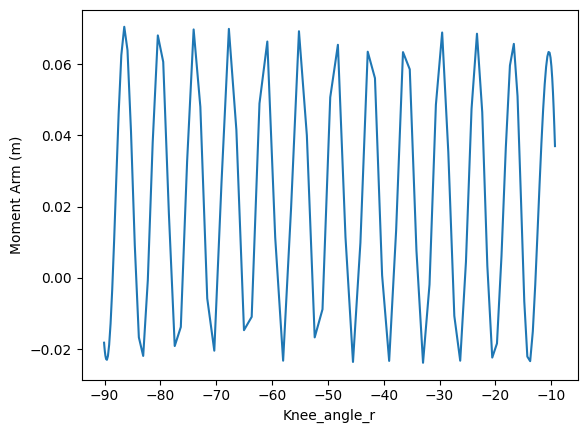

In [27]:
# Plot Muscle Moment Arms
load_and_plot_mas('hamstrings_r', 'knee_angle_r', df=kin, xaxis='knee_angle_r')

### Static Optimization

In [64]:
%%kpy


analyze = osim.AnalyzeTool('/content/analyze_tool_setup.xml')
analyze.run()


[info] AbstractTool  loading model /content/locked_gait10dof18musc_updated.osim
[info] Updating Model file from 30000 to latest format...
[info] Loaded model gait10dof18musc.osim from file /content/locked_gait10dof18musc_updated.osim
[warning] Couldn't find file 'sacrum.vtp'.
[warning] Couldn't find file 'pelvis.vtp'.
[warning] Couldn't find file 'l_pelvis.vtp'.
[warning] Couldn't find file 'femur_r.vtp'.
[warning] Couldn't find file 'tibia_r.vtp'.
[warning] Couldn't find file 'fibula.vtp'.
[warning] Couldn't find file 'talus.vtp'.
[warning] Couldn't find file 'foot.vtp'.
[warning] Couldn't find file 'bofoot.vtp'.
[warning] Couldn't find file 'femur_l.vtp'.
[warning] Couldn't find file 'tibia_l.vtp'.
[warning] Couldn't find file 'l_fibula.vtp'.
[warning] Couldn't find file 'l_talus.vtp'.
[warning] Couldn't find file 'l_foot.vtp'.
[warning] Couldn't find file 'l_bofoot.vtp'.
[warning] Couldn't find file 'hat_spine.vtp'.
[warning] Couldn't find file 'hat_jaw.vtp'.
[warning] Couldn't find

In [66]:
force_df = pd.read_csv("/content/results/_StaticOptimization_force.sto", sep='\t', header=10)

display(force_df)

,time,hamstrings_r,bifemsh_r,glut_max_r,iliopsoas_r,rect_fem_r,vasti_r,gastroc_r,soleus_r,tib_ant_r,hamstrings_l,bifemsh_l,glut_max_l,iliopsoas_l,rect_fem_l,vasti_l,gastroc_l,soleus_l,tib_ant_l
0,0.000000,27.097242,13.302301,19.512805,223.861460,27.814685,50.098620,33.222783,52.054439,104.524220,32.813133,9.771022,23.625455,28.462354,14.206871,60.765060,30.382530,62.430023,36.459036
1,0.101010,27.077750,14.760526,19.503083,278.054798,34.390783,50.101850,38.583701,51.951772,109.473147,32.699239,9.737107,23.543452,28.363562,14.157560,60.554147,30.277073,62.213331,36.332488
2,0.202020,27.086378,18.934368,19.502808,291.392201,23.615087,50.102217,56.808659,51.803366,125.958153,32.701734,9.737850,23.545249,28.365727,14.158640,60.558767,30.279384,62.218077,36.335260
3,0.303030,27.039110,20.955943,19.477123,526.329163,88.247768,50.102946,58.830415,51.781965,129.959055,33.891575,10.092158,24.401934,29.397803,14.673797,62.762175,31.381088,64.481859,37.657305
4,0.404040,27.037464,30.283862,19.476218,600.360378,87.556482,50.071710,84.099872,51.660185,151.839534,33.708154,10.037539,24.269871,29.238703,14.594382,62.422508,31.211254,64.132885,37.453505
5,0.505051,27.064985,51.243687,19.485163,539.241003,24.096498,50.046752,140.542863,51.616876,193.939431,33.371979,9.937434,24.027825,28.947102,14.448831,61.799961,30.899980,63.493280,37.079977
6,0.606061,27.055486,57.026356,19.486242,626.737851,43.278799,50.044683,169.264216,51.588455,212.090960,33.301936,9.916577,23.977394,28.886346,14.418505,61.670252,30.835126,63.360017,37.002151
7,0.707071,27.071297,56.918921,19.498135,611.422499,35.894731,50.046679,175.065973,51.597375,209.188234,33.140177,9.868408,23.860927,28.746035,14.348469,61.370698,30.685349,63.052255,36.822419
8,0.808081,27.113457,55.212738,19.518684,521.511928,20.848236,50.048323,178.862205,51.597998,207.689329,33.054989,9.843041,23.799592,28.672142,14.311586,61.212942,30.606471,62.890177,36.727765
9,0.909091,27.056443,49.435369,19.505671,666.843981,65.591451,50.050534,157.868364,51.588109,200.166190,33.001496,9.827112,23.761077,28.625742,14.288426,61.113882,30.556941,62.788402,36.668329
